### 5.2 데이터 분석과 전처리

#### 02. 데이터 분석과 전처리

데이터 불러오기와 분석하기

> kaggle competitions download -c quora-question-pairs (캐글 사이트에서 참여해야 함)

https://www.kaggle.com/c/quora-question-pairs/data

In [1]:
import zipfile

In [2]:
# zip 파일 압축 해제
DATA_IN_PATH = './data_in/'
file_list = ["train.csv.zip", "test.csv.zip", "sample_submission.csv.zip"]

for file in file_list:
    zipRef = zipfile.ZipFile(DATA_IN_PATH + file, 'r')
    zipRef.extractall(DATA_IN_PATH)
    zipRef.close()

In [3]:
import numpy as np 
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
train_data = pd.read_csv(DATA_IN_PATH + 'train.csv')
train_data.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [5]:
print("파일 크기 : ")
for file in os.listdir(DATA_IN_PATH):
    if 'csv' in file and 'zip' not in file:
        print(file.ljust(30) + str(round(os.path.getsize(DATA_IN_PATH + file) / 1000000, 2)) + 'MB')

파일 크기 : 
sample_submission.csv         22.35MB
test.csv                      477.59MB
train.csv                     63.4MB


In [6]:
print('전체 학습데이터의 개수: {}'.format(len(train_data)))

전체 학습데이터의 개수: 404290


1. 질문 중복 분석

In [7]:
train_set = pd.Series(train_data['question1'].tolist() + train_data['question2'].tolist()).astype(str)
train_set.head()

0    What is the step by step guide to invest in sh...
1    What is the story of Kohinoor (Koh-i-Noor) Dia...
2    How can I increase the speed of my internet co...
3    Why am I mentally very lonely? How can I solve...
4    Which one dissolve in water quikly sugar, salt...
dtype: object

In [8]:
print('교육 데이터의 총 질문 수: {}'.format(len(np.unique(train_set))))
print('반복해서 나타나는 질문의 수: {}'.format(np.sum(train_set.value_counts() > 1)))

교육 데이터의 총 질문 수: 537361
반복해서 나타나는 질문의 수: 111873


d:\anaconda3\envs\pr_tensorflow\lib\site-packages\ipykernel_launcher.py:11: MatplotlibDeprecationWarning: The 'nonposy' parameter of __init__() has been renamed 'nonpositive' since Matplotlib 3.3; support for the old name will be dropped two minor releases later.
  # This is added back by InteractiveShellApp.init_path()


Text(0, 0.5, 'Number of questions')

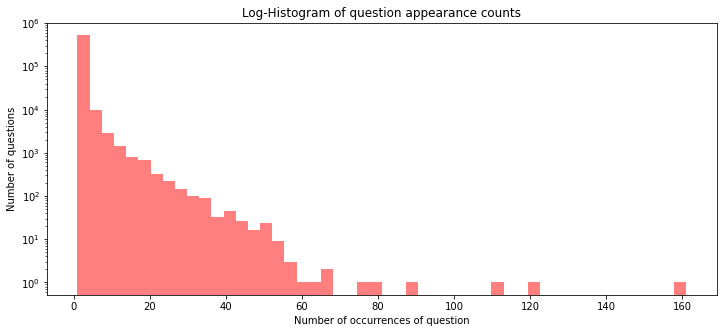

In [9]:
# 그래프에 대한 이미지 사이즈 선언
# figsize: (가로, 세로) 형태의 튜플로 입력
plt.figure(figsize=(12, 5))
# 히스토그램 선언
# bins: 히스토그램 값들에 대한 버켓 범위
# range: x축 값의 범위
# alpha: 그래프 색상 투명도
# color: 그래프 색상
# label: 그래프에 대한 라벨
plt.hist(train_set.value_counts(), bins=50, alpha=0.5, color= 'r', label='word')
plt.yscale('log', nonposy='clip')

# 그래프 제목
plt.title('Log-Histogram of question appearance counts')

# 그래프 x 축 라벨
plt.xlabel('Number of occurrences of question')

# 그래프 y 축 라벨
plt.ylabel('Number of questions')

In [10]:
print('중복 최대 개수: {}'.format(np.max(train_set.value_counts())))
print('중복 최소 개수: {}'.format(np.min(train_set.value_counts())))
print('중복 평균 개수: {:.2f}'.format(np.mean(train_set.value_counts())))
print('중복 표준편차: {:.2f}'.format(np.std(train_set.value_counts())))
print('중복 중간길이: {}'.format(np.median(train_set.value_counts())))

# 사분위의 대한 경우는 0~100 스케일로 되어있음
print('제 1 사분위 중복: {}'.format(np.percentile(train_set.value_counts(), 25)))
print('제 3 사분위 중복: {}'.format(np.percentile(train_set.value_counts(), 75)))

중복 최대 개수: 161
중복 최소 개수: 1
중복 평균 개수: 1.50
중복 표준편차: 1.91
중복 중간길이: 1.0
제 1 사분위 중복: 1.0
제 3 사분위 중복: 1.0


{'whiskers': [<matplotlib.lines.Line2D at 0x12b3a83b5f8>,
 'caps': [<matplotlib.lines.Line2D at 0x12b3a83bba8>,
 'boxes': [<matplotlib.lines.Line2D at 0x12b3a83b390>],
 'medians': [<matplotlib.lines.Line2D at 0x12b3a84a198>],
 'fliers': [<matplotlib.lines.Line2D at 0x12b3a84a668>],
 'means': [<matplotlib.lines.Line2D at 0x12b3a84a470>]}

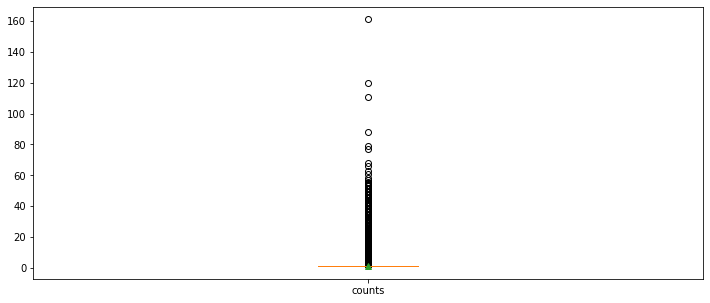

In [11]:
# 중복 질문 횟수 박스플롯
plt.figure(figsize=(12, 5))
# 박스플롯 생성
# 첫번째 파라메터: 여러 분포에 대한 데이터 리스트를 입력
# labels: 입력한 데이터에 대한 라벨
# showmeans: 평균값을 마크함

plt.boxplot([train_set.value_counts()],
            labels=['counts'],
            showmeans=True)

(-0.5, 799.5, 599.5, -0.5)

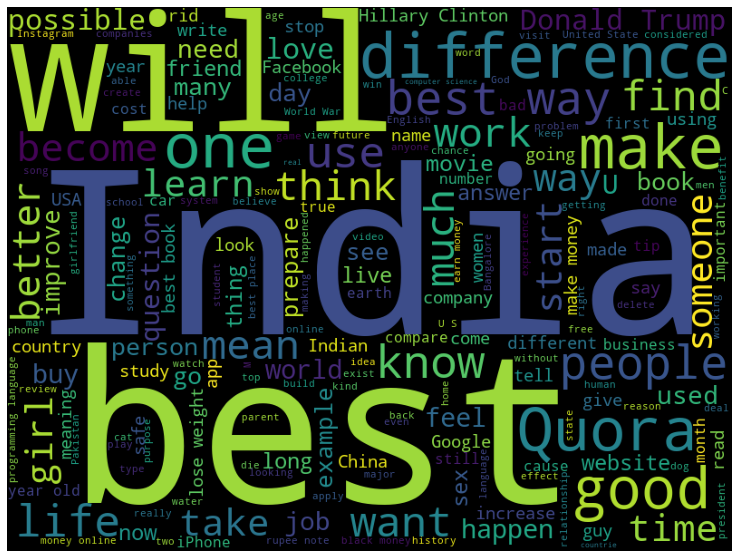

In [12]:
from wordcloud import WordCloud
cloud = WordCloud(width=800, height=600).generate(" ".join(train_set.astype(str)))

plt.figure(figsize=(15, 10))
plt.imshow(cloud)
plt.axis('off')

2. 라벨 빈도 분석

d:\anaconda3\envs\pr_tensorflow\lib\site-packages\seaborn\_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


<AxesSubplot:xlabel='is_duplicate', ylabel='count'>

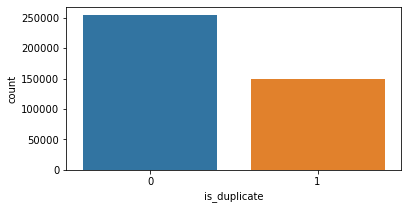

In [13]:
fig, axe = plt.subplots(ncols=1)
fig.set_size_inches(6, 3)
sns.countplot(train_data['is_duplicate'])

# 중복 질문 수: 약 150,000개
# 고유 질문 수: 약 250,000개

3. 텍스트 길이 분석 (문자 단위)

In [14]:
train_length = train_set.apply(len)
print(train_length)

0          66
1          51
2          73
3          50
4          76
         ... 
808575     79
808576     42
808577     17
808578    127
808579     45
Length: 808580, dtype: int64


Text(0, 0.5, 'Probability')

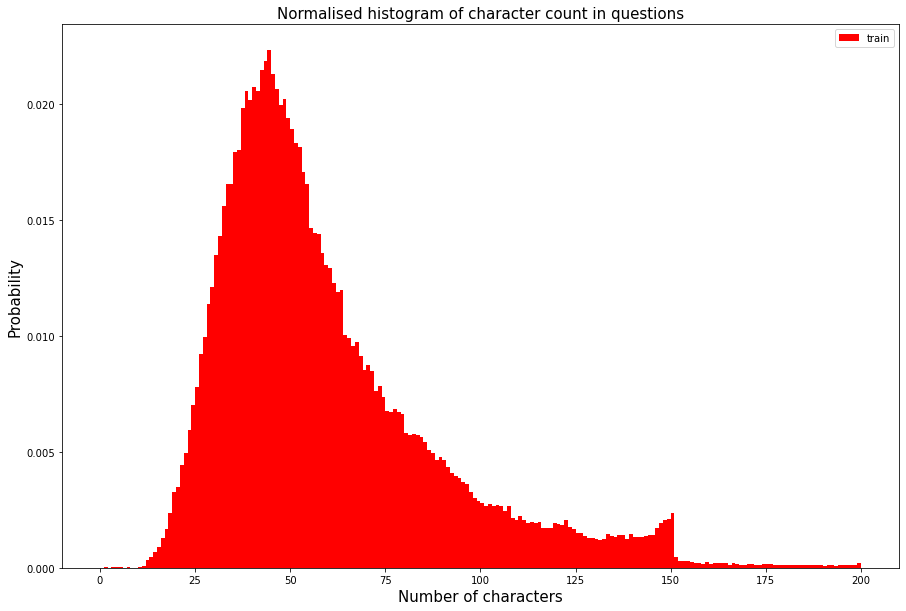

In [15]:
# 각 데이터의 길이값 히스토그램
plt.figure(figsize=(15, 10))
plt.hist(train_length, bins=200, range=[0,200], facecolor='r', density=True, label='train')
plt.title("Normalised histogram of character count in questions", fontsize=15)
plt.legend()
plt.xlabel('Number of characters', fontsize=15)
plt.ylabel('Probability', fontsize=15)

In [16]:
print('질문 길이 최대 값: {}'.format(np.max(train_length)))
print('질문 길이 평균 값: {:.2f}'.format(np.mean(train_length)))
print('질문 길이 표준편차: {:.2f}'.format(np.std(train_length)))
print('질문 길이 중간 값: {}'.format(np.median(train_length)))
print('질문 길이 제 1 사분위: {}'.format(np.percentile(train_length, 25)))
print('질문 길이 제 3 사분위: {}'.format(np.percentile(train_length, 75)))

질문 길이 최대 값: 1169
질문 길이 평균 값: 59.82
질문 길이 표준편차: 31.96
질문 길이 중간 값: 51.0
질문 길이 제 1 사분위: 39.0
질문 길이 제 3 사분위: 72.0


{'whiskers': [<matplotlib.lines.Line2D at 0x12b3a633f98>,
 'caps': [<matplotlib.lines.Line2D at 0x12b3a6f5358>,
 'boxes': [<matplotlib.lines.Line2D at 0x12b3a693080>],
 'medians': [<matplotlib.lines.Line2D at 0x12b3a78c128>],
 'fliers': [<matplotlib.lines.Line2D at 0x12b3a78c5f8>],
 'means': [<matplotlib.lines.Line2D at 0x12b3a78c400>]}

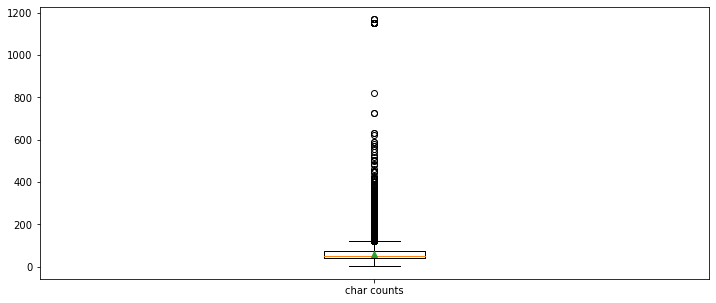

In [17]:
# 질문 길이값 박스플롯
plt.figure(figsize=(12, 5))

plt.boxplot(train_length,
            labels=['char counts'],
            showmeans=True)

4. 텍스트 길이 분석 (단어 단위)

Text(0, 0.5, 'Prabability')

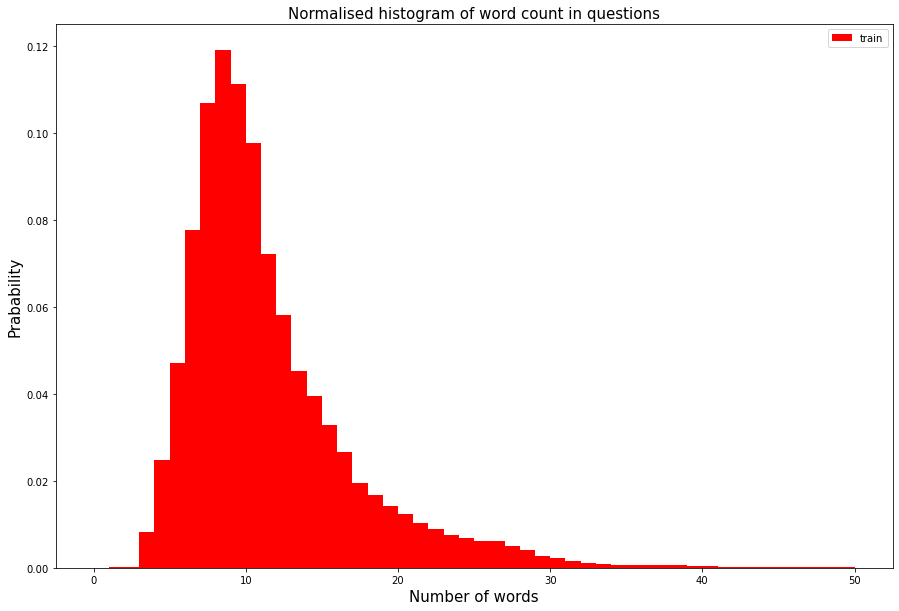

In [18]:
# 단어 개수로 길이값 분석
train_word_counts = train_set.apply(lambda x:len(x.split(' ')))

plt.figure(figsize=(15, 10))
plt.hist(train_word_counts, bins=50, range=[0, 50], facecolor='r', density=True, label='train')
plt.title('Normalised histogram of word count in questions', fontsize=15)
plt.legend()
plt.xlabel('Number of words', fontsize=15)
plt.ylabel('Prabability', fontsize=15)

In [19]:
print('질문 단어 개수 최대 값: {}'.format(np.max(train_word_counts)))
print('질문 단어 개수 평균 값: {:.2f}'.format(np.mean(train_word_counts)))
print('질문 단어 개수 표준편차: {:.2f}'.format(np.std(train_word_counts)))
print('질문 단어 개수 중간 값: {}'.format(np.median(train_word_counts)))
print('질문 단어 개수 제 1 사분위: {}'.format(np.percentile(train_word_counts, 25)))
print('질문 단어 개수 제 3 사분위: {}'.format(np.percentile(train_word_counts, 75)))
print('질문 단어 개수 99 퍼센트: {}'.format(np.percentile(train_word_counts, 99)))

질문 단어 개수 최대 값: 237
질문 단어 개수 평균 값: 11.06
질문 단어 개수 표준편차: 5.89
질문 단어 개수 중간 값: 10.0
질문 단어 개수 제 1 사분위: 7.0
질문 단어 개수 제 3 사분위: 13.0
질문 단어 개수 99 퍼센트: 31.0


{'whiskers': [<matplotlib.lines.Line2D at 0x12b3af370f0>,
 'caps': [<matplotlib.lines.Line2D at 0x12b3af376d8>,
 'boxes': [<matplotlib.lines.Line2D at 0x12b3af48278>],
 'medians': [<matplotlib.lines.Line2D at 0x12b3af37da0>],
 'fliers': [<matplotlib.lines.Line2D at 0x12b3af290f0>],
 'means': [<matplotlib.lines.Line2D at 0x12b3af299b0>]}

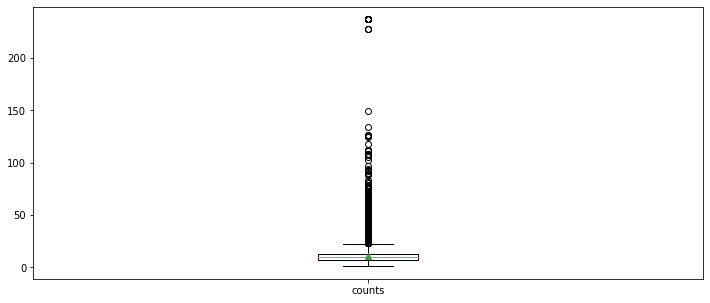

In [20]:
plt.figure(figsize=(12, 5))

plt.boxplot(train_word_counts,
            labels=['counts'],
            showmeans=True)

In [21]:
qmarks = np.mean(train_set.apply(lambda x: '?' in x)) # 물음표가 구두점으로 쓰임
math = np.mean(train_set.apply(lambda x: '[math]' in x)) # []
fullstop = np.mean(train_set.apply(lambda x: '.' in x)) # 마침표
capital_first = np.mean(train_set.apply(lambda x: x[0].isupper())) #  첫번째 대문자
capitals = np.mean(train_set.apply(lambda x: max([y.isupper() for y in x]))) # 대문자가 몇개
numbers = np.mean(train_set.apply(lambda x: max([y.isdigit() for y in x]))) # 숫자가 몇개

print('물음표가있는 질문: {:.2f}%'.format(qmarks * 100))
print('수학 태그가있는 질문: {:.2f}%'.format(math * 100))
print('마침표를 포함한 질문: {:.2f}%'.format(fullstop * 100))
print('첫 글자가 대문자 인 질문: {:.2f}%'.format(capital_first * 100))
print('대문자가있는 질문: {:.2f}%'.format(capitals * 100))
print('숫자가있는 질문: {:.2f}%'.format(numbers * 100))

물음표가있는 질문: 99.87%
수학 태그가있는 질문: 0.12%
마침표를 포함한 질문: 6.31%
첫 글자가 대문자 인 질문: 99.81%
대문자가있는 질문: 99.95%
숫자가있는 질문: 11.83%


데이터 전처리

In [22]:
import pandas as pd
import numpy as np
import re
import json

from tensorflow.python.keras.preprocessing.text import Tokenizer
from tensorflow.python.keras.preprocessing.sequence import pad_sequences

In [23]:
DATA_IN_PATH = './data_in/'

train_data = pd.read_csv(DATA_IN_PATH + 'train.csv', encoding='utf-8')
train_data.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [24]:
# 라벨 개수 균형 맞추기
train_pos_data = train_data.loc[train_data['is_duplicate'] == 1]
train_neg_data = train_data.loc[train_data['is_duplicate'] == 0]

class_difference = len(train_neg_data) - len(train_pos_data)
sample_frac = 1 - (class_difference / len(train_neg_data))

train_neg_data = train_neg_data.sample(frac = sample_frac)

print("중복 질문 개수: {}".format(len(train_pos_data)))
print("중복이 아닌 질문 개수: {}".format(len(train_neg_data)))

중복 질문 개수: 149263
중복이 아닌 질문 개수: 149263


In [25]:
# 데이터 합치기
train_data = pd.concat([train_pos_data, train_neg_data])
train_data.head()

,id,qid1,qid2,question1,question2,is_duplicate
5,5,11,12,Astrology: I am a Capricorn Sun Cap moon and c...,"I'm a triple Capricorn (Sun, Moon and ascendan...",1
7,7,15,16,How can I be a good geologist?,What should I do to be a great geologist?,1
11,11,23,24,How do I read and find my YouTube comments?,How can I see all my Youtube comments?,1
12,12,25,26,What can make Physics easy to learn?,How can you make physics easy to learn?,1
13,13,27,28,What was your first sexual experience like?,What was your first sexual experience?,1


In [26]:
# 텍스트 전처리
FILTERS = "([~.,!?\"':;)(])"
change_filter = re.compile(FILTERS)

questions1 = [str(s) for s in train_data['question1']]
questions2 = [str(s) for s in train_data['question2']]

filtered_questions1 = list()
filtered_questions2 = list()

for q in questions1:
    filtered_questions1.append(re.sub(change_filter, "", q).lower())
        
for q in questions2:
    filtered_questions2.append(re.sub(change_filter, "", q).lower())

In [27]:
# 토크나이징 객체 생성
tokenizer = Tokenizer()
tokenizer.fit_on_texts(filtered_questions1 + filtered_questions2) 

# 각 질문에 대해 토크나이징을 따로 진행
# 2개 질문에 대해 토크나이징 방식을 동일하게 진행하고 두 질문을 합쳐 전체 단어 사전을 만들기 위함.
questions1_sequence = tokenizer.texts_to_sequences(filtered_questions1)
questions2_sequence = tokenizer.texts_to_sequences(filtered_questions2)

# 패딩: 최대 길이 지정 후 긴 질문은 자르고, 짧은 질문은 0으로 채움
MAX_SEQUENCE_LENGTH = 31  # 질문 단어 개수 99 퍼센트

q1_data = pad_sequences(questions1_sequence, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
q2_data = pad_sequences(questions2_sequence, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

In [28]:
# 단어 사전 생성
word_vocab = {}
word_vocab = tokenizer.word_index 
word_vocab["<PAD>"] = 0

# 라벨 데이터 생성
labels = np.array(train_data['is_duplicate'], dtype=int)

print('Shape of question1 data: {}'.format(q1_data.shape))
print('Shape of question2 data:{}'.format(q2_data.shape))
print('Shape of label: {}'.format(labels.shape))
print("Words in index: {}".format(len(word_vocab)))

Shape of question1 data: (298526, 31)
Shape of question2 data:(298526, 31)
Shape of label: (298526,)
Words in index: 76455


In [29]:
print(word_vocab)

{'the': 1, 'what': 2, 'is': 3, 'how': 4, 'i': 5, 'to': 6, 'a': 7, 'in': 8, 'do': 9, 'of': 10, 'are': 11, 'and': 12, 'can': 13, 'for': 14, 'you': 15, 'why': 16, 'best': 17, 'my': 18, 'it': 19, 'on': 20, 'does': 21, 'which': 22, 'be': 23, 'if': 24, 'some': 25, 'or': 26, 'get': 27, 'that': 28, 'have': 29, 'should': 30, 'with': 31, 'your': 32, 'an': 33, 'from': 34, 'india': 35, 'will': 36, 'people': 37, 'who': 38, 'when': 39, 'like': 40, 'good': 41, 'would': 42, 'at': 43, 'there': 44, 'as': 45, 'about': 46, 'quora': 47, 'between': 48, 'most': 49, 'one': 50, 'way': 51, 'not': 52, 'we': 53, 'make': 54, 'did': 55, 'life': 56, 'where': 57, 'by': 58, 'money': 59, 'was': 60, 'any': 61, 'so': 62, 'time': 63, 'me': 64, 'after': 65, 'learn': 66, 'they': 67, 'know': 68, 'this': 69, 'has': 70, 'whats': 71, 'difference': 72, 'new': 73, 'think': 74, 'use': 75, 'trump': 76, 'am': 77, 'ever': 78, 'much': 79, 'indian': 80, 'all': 81, 'their': 82, 'many': 83, 'us': 84, 'become': 85, 'someone': 86, 'work': 

In [30]:
data_configs = {}
data_configs['vocab'] = word_vocab
data_configs['vocab_size'] = len(word_vocab)

print(data_configs)

{'vocab': {'the': 1, 'what': 2, 'is': 3, 'how': 4, 'i': 5, 'to': 6, 'a': 7, 'in': 8, 'do': 9, 'of': 10, 'are': 11, 'and': 12, 'can': 13, 'for': 14, 'you': 15, 'why': 16, 'best': 17, 'my': 18, 'it': 19, 'on': 20, 'does': 21, 'which': 22, 'be': 23, 'if': 24, 'some': 25, 'or': 26, 'get': 27, 'that': 28, 'have': 29, 'should': 30, 'with': 31, 'your': 32, 'an': 33, 'from': 34, 'india': 35, 'will': 36, 'people': 37, 'who': 38, 'when': 39, 'like': 40, 'good': 41, 'would': 42, 'at': 43, 'there': 44, 'as': 45, 'about': 46, 'quora': 47, 'between': 48, 'most': 49, 'one': 50, 'way': 51, 'not': 52, 'we': 53, 'make': 54, 'did': 55, 'life': 56, 'where': 57, 'by': 58, 'money': 59, 'was': 60, 'any': 61, 'so': 62, 'time': 63, 'me': 64, 'after': 65, 'learn': 66, 'they': 67, 'know': 68, 'this': 69, 'has': 70, 'whats': 71, 'difference': 72, 'new': 73, 'think': 74, 'use': 75, 'trump': 76, 'am': 77, 'ever': 78, 'much': 79, 'indian': 80, 'all': 81, 'their': 82, 'many': 83, 'us': 84, 'become': 85, 'someone': 86

In [31]:
TRAIN_Q1_DATA = 'train_q1.npy'
TRAIN_Q2_DATA = 'train_q2.npy'
TRAIN_LABEL_DATA = 'train_label.npy'
DATA_CONFIGS = 'data_configs.json'

np.save(open(DATA_IN_PATH + TRAIN_Q1_DATA, 'wb'), q1_data)
np.save(open(DATA_IN_PATH + TRAIN_Q2_DATA , 'wb'), q2_data)
np.save(open(DATA_IN_PATH + TRAIN_LABEL_DATA , 'wb'), labels)

json.dump(data_configs, open(DATA_IN_PATH + DATA_CONFIGS, 'w'))

In [32]:
test_data = pd.read_csv(DATA_IN_PATH + 'test.csv', encoding='utf-8')
# test_data = test_data.drop(test_data.tail(1217679).index,inplace=True) # drop last n rows

valid_ids = [type(x) ==int for x in test_data.test_id] 
test_data = test_data[valid_ids].drop_duplicates()

d:\anaconda3\envs\pr_tensorflow\lib\site-packages\IPython\core\interactiveshell.py:3072: DtypeWarning: Columns (0) have mixed types.Specify dtype option on import or set low_memory=False.
  interactivity=interactivity, compiler=compiler, result=result)


In [33]:
# 평가 데이터 전처리
test_questions1 = [str(s) for s in test_data['question1']]
test_questions2 = [str(s) for s in test_data['question2']]

filtered_test_questions1 = list()
filtered_test_questions2 = list()

for q in test_questions1:
    filtered_test_questions1.append(re.sub(change_filter, "", q).lower())
        
for q in test_questions2:
    filtered_test_questions2.append(re.sub(change_filter, "", q).lower())

In [34]:
# 이전에 학습한 토크나이저로 텍스트 시퀀스 생성
test_questions1_sequence = tokenizer.texts_to_sequences(filtered_test_questions1)
test_questions2_sequence = tokenizer.texts_to_sequences(filtered_test_questions2)

test_q1_data = pad_sequences(test_questions1_sequence, maxlen=MAX_SEQUENCE_LENGTH, padding='post')
test_q2_data = pad_sequences(test_questions2_sequence, maxlen=MAX_SEQUENCE_LENGTH, padding='post')

test_id = np.array(test_data['test_id'])

print('Shape of question1 data: {}'.format(test_q1_data.shape))
print('Shape of question2 data:{}'.format(test_q2_data.shape))
print('Shape of ids: {}'.format(test_id.shape))

Shape of question1 data: (2345796, 31)
Shape of question2 data:(2345796, 31)
Shape of ids: (2345796,)


In [35]:
TEST_Q1_DATA = 'test_q1.npy'
TEST_Q2_DATA = 'test_q2.npy'
TEST_ID_DATA = 'test_id.npy'

np.save(open(DATA_IN_PATH + TEST_Q1_DATA, 'wb'), test_q1_data)
np.save(open(DATA_IN_PATH + TEST_Q2_DATA , 'wb'), test_q2_data)
np.save(open(DATA_IN_PATH + TEST_ID_DATA , 'wb'), test_id)

#### 03. 모델링

XGBoost 텍스트 유사도 분석 모델
- `배깅(Bagging)`: 여러 학습 모델을 통해 각각 결과를 예측하고 모든 결과를 동등하게 보고 취합해서 결과를 얻는 방식. `ex) Random Forest`
- `부스팅(Boosting)`: 각 결과를 순차적으로 취합하는데, 단순히 하나씩 취합하는 방법이 아니라 이전 알고리즘, 모델이 학습 후 잘못 예측한 부분에 가중치를 줘서 다시 모델로 가서 학습하는 방식

모델 구현

In [36]:
import numpy as np
import pandas as pd

DATA_IN_PATH = './data_in/'

TRAIN_Q1_DATA_FILE = 'train_q1.npy'
TRAIN_Q2_DATA_FILE = 'train_q2.npy'
TRAIN_LABEL_DATA_FILE = 'train_label.npy'

# 훈련 데이터 로드
train_q1_data = np.load(open(DATA_IN_PATH + TRAIN_Q1_DATA_FILE, 'rb'))
train_q2_data = np.load(open(DATA_IN_PATH + TRAIN_Q2_DATA_FILE, 'rb'))
train_labels = np.load(open(DATA_IN_PATH + TRAIN_LABEL_DATA_FILE, 'rb'))

# 두 질문을 하나의 입력으로 합침
# (질문1, 질문2) 형태로 묶음
train_input = np.stack((train_q1_data, train_q2_data), axis=1)

print('훈련 데이터 입력 크기: {}'.format(train_input.shape))
#print(train_input)

훈련 데이터 입력 크기: (298526, 2, 31)


In [37]:
from sklearn.model_selection import train_test_split
import xgboost as xgb

train_input, eval_input, train_label, eval_label = train_test_split(
    train_input, train_labels, test_size = 0.2, random_state=4242
)

train_data = xgb.DMatrix(train_input.sum(axis=1),  # 각 데이터의 두 질문을 하나의 값으로 합침 
                        label=train_label)
eval_data = xgb.DMatrix(eval_input.sum(axis=1), 
                        label=eval_label)

data_list = [(train_data, 'train'), (eval_data, 'eval')]

params = {
    "objective": "binary:logistic",  # 이진 분류
    "eval_metric": "rmse",        # 평가 지표: RMSE
}

bst = xgb.train(params, train_data, num_boost_round=1000, 
                evals=data_list, early_stopping_rounds=10)

[0]	train-rmse:0.48371	eval-rmse:0.48405
[1]	train-rmse:0.47336	eval-rmse:0.47396
[2]	train-rmse:0.46657	eval-rmse:0.46759
[3]	train-rmse:0.46175	eval-rmse:0.46295
[4]	train-rmse:0.45807	eval-rmse:0.45930
[5]	train-rmse:0.45540	eval-rmse:0.45671
[6]	train-rmse:0.45343	eval-rmse:0.45488
[7]	train-rmse:0.45065	eval-rmse:0.45218
[8]	train-rmse:0.44934	eval-rmse:0.45103
[9]	train-rmse:0.44796	eval-rmse:0.44976
[10]	train-rmse:0.44714	eval-rmse:0.44901
[11]	train-rmse:0.44577	eval-rmse:0.44780
[12]	train-rmse:0.44533	eval-rmse:0.44746
[13]	train-rmse:0.44303	eval-rmse:0.44539
[14]	train-rmse:0.44255	eval-rmse:0.44510
[15]	train-rmse:0.44174	eval-rmse:0.44448
[16]	train-rmse:0.44030	eval-rmse:0.44310
[17]	train-rmse:0.43992	eval-rmse:0.44278
[18]	train-rmse:0.43959	eval-rmse:0.44260
[19]	train-rmse:0.43933	eval-rmse:0.44242
[20]	train-rmse:0.43900	eval-rmse:0.44218
[21]	train-rmse:0.43842	eval-rmse:0.44167
[22]	train-rmse:0.43785	eval-rmse:0.44131
[23]	train-rmse:0.43769	eval-rmse:0.44123
[2

In [5]:
# 전처리한 평가 데이터 로드
import os

TEST_Q1_DATA_FILE = 'test_q1.npy'
TEST_Q2_DATA_FILE = 'test_q2.npy'
TEST_ID_DATA_FILE = 'test_id.npy'

test_q1_data = np.load(open(DATA_IN_PATH + TEST_Q1_DATA_FILE, 'rb'), allow_pickle=True)
test_q2_data = np.load(open(DATA_IN_PATH + TEST_Q2_DATA_FILE, 'rb'), allow_pickle=True)
test_id_data = np.load(open(DATA_IN_PATH + TEST_ID_DATA_FILE, 'rb'), allow_pickle=True)

# 두 질문을 하나의 입력으로 합침
test_input = np.stack((test_q1_data, test_q2_data), axis=1)

# 모델 예측
test_data = xgb.DMatrix(test_input.sum(axis=1))
test_predict = bst.predict(test_data)

# 결과 저장
DATA_OUT_PATH = './data_out/'

if not os.path.exists(DATA_OUT_PATH):
    os.makedirs(DATA_OUT_PATH)

output = pd.DataFrame(
    {'test_id': test_id_data, 
    'is_duplicate': test_predict
})

output.to_csv(DATA_OUT_PATH + 'simple_xgb.csv', index=False)

CNN 텍스트 유사도 분석 모델

학습 데이터 불러오기

In [38]:
import tensorflow as tf
from tensorflow.python.keras.preprocessing.sequence import pad_sequences
from tensorflow.python.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.python.keras import layers
import numpy as np
import json

In [39]:
DATA_IN_PATH = './data_in/'
DATA_OUT_PATH = './data_out/'

TRAIN_Q1_DATA_FILE = 'train_q1.npy'
TRAIN_Q2_DATA_FILE = 'train_q2.npy'
TRAIN_LABEL_DATA_FILE = 'train_label.npy'
DATA_CONFIGS = 'data_configs.json'

q1_data = np.load(open(DATA_IN_PATH + TRAIN_Q1_DATA_FILE, 'rb'))
q2_data = np.load(open(DATA_IN_PATH + TRAIN_Q2_DATA_FILE, 'rb'))
labels = np.load(open(DATA_IN_PATH + TRAIN_LABEL_DATA_FILE, 'rb'))
prepro_configs = json.load(open(DATA_IN_PATH + DATA_CONFIGS, "r"))  # 사전 정보. 워드 임베딩에 사용

모델 구현

In [44]:
# 문장에 대한 정보를 하나의 벡터로 변환하는 레이어(문장 임베딩 레이어)
# 합성곱 신경망(CNN) 기반

class SentenceEmbedding(layers.Layer):
    def __init__(self, **kwargs):
        super(SentenceEmbedding, self).__init__()
        
        # 합성곱 레이어
        self.conv = layers.Conv1D(
            kwargs["conv_num_filters"],  # 필터의 개수
            kwargs["conv_window_size"],  # 필터의 크기
            activation=tf.keras.activations.relu,  # 활성화 함수
            padding='same'  # 패딩 방식
        )
        
        # 맥스풀 레이어
        self.max_pool = layers.MaxPool1D(
            kwargs["max_pool_seq_len"],  # 풀링 영역 크기
            1                
        )
        
        # 차원 수 조절을 위한 Dense 레이어
        self.dense = layers.Dense(
            kwargs["sent_embedding_dimension"],  # 문장 임베딩 벡터로 출력할 차원 수
            activation = tf.keras.activations.relu
        )
    
    # 모듈 연산 과정 정의 함수
    def call(self, x):
        x = self.conv(x)
        x = self.max_pool(x)
        x = self.dense(x)
        
        return tf.squeeze(x, axis=1)  # 불필요한 차원 제거

# 문장 유사도 모델
class SentencSimilarityModel(tf.keras.Model):
    def __init__(self, **kwargs):
        super(SentencSimilarityModel, self).__init__(name = kwargs["model_name"])
        
        # 단어 임베딩 레이어
        self.word_embedding = layers.Embedding(
            kwargs["vocab_size"],  # 단어 사전 크기
            kwargs["word_embedding_dimension"],  # 워드 임베딩 벡터 차원
        )
        
        # 문장 임베딩 레이어
        self.base_encoder = SentenceEmbedding(**kwargs)
        self.hypo_encoder = SentenceEmbedding(**kwargs)
        
        # 두 base와 hypothesis 문장에 대한 유사도 계산을 위한 레이어
        self.dense = layers.Dense(
            kwargs["hidden_dimension"],  # 출력하는 벡터의 크기 정의
            activation=tf.keras.activations.relu
        )

        # 두 문장 간의 유사성이 있는지 하나의 값으로 표현하는 레이어(0 ~ 1 값)
        self.logit = layers.Dense(1, activation=tf.keras.activations.sigmoid)
        self.dropout = layers.Dropout(rate=kwargs["dropout_rate"])
        
    def call(self, x):
        x1, x2 = x
        b_x = self.word_embedding(x1)
        h_x = self.word_embedding(x2)
        
        b_x = self.dropout(b_x)
        h_x = self.dropout(h_x)
        
        b_x = self.base_encoder(b_x)
        h_x = self.hypo_encoder(h_x)
        
        e_x = tf.concat([b_x, h_x], -1)
        e_x = self.dense(e_x)
        e_x = self.dropout(e_x)
        
        return self.logit(e_x)

모델 하이퍼파라미터 정의

In [41]:
model_name = "cnn_similarity"
BATCH_SIZE = 1024
NUM_EPOCHS = 100
VALID_SPLIT = 0.1
MAX_LEN = 31

kwargs = {
    "model_name" : model_name,
    "vocab_size" : prepro_configs["vocab_size"],
    "word_embedding_dimension" : 100,
    "conv_num_filters" : 300,
    "conv_window_size" : 3,
    "max_pool_seq_len" : MAX_LEN,
    "sent_embedding_dimension" : 128,
    "dropout_rate" : 0.2,
    "hidden_dimension" : 200,
    "output_dimension" : 11
}

모델 생성

In [45]:
Model = SentencSimilarityModel(**kwargs)

Model.compile(
    optimizer = tf.keras.optimizers.Adam(1e-3),
    loss = tf.keras.losses.BinaryCrossentropy(),
    metrics = [tf.keras.metrics.BinaryAccuracy(name = "accuracy")]
)

모델 학습

In [46]:
# 오버피팅을 막기 위한 earlystop 추가
earlystop_callboack = EarlyStopping(
    monitor = "val_accuracy", min_delta = 0.0001, patience = 1
)

checkpoint_path = DATA_OUT_PATH + model_name + "/weights.h5"
checkpoint_dir = os.path.dirname(checkpoint_path)

if os.path.exists(checkpoint_dir):
    print("{} -- Folder already exists \n".format(checkpoint_dir))
else:
    os.makedirs(checkpoint_dir, exist_ok=True)
    print("{} -- Folder create complete \n".format(checkpoint_dir))

cp_callback = ModelCheckpoint(
    checkpoint_path, monitor = "val_accuracy", verbose = 1, save_best_only = True,
    save_weights_only = True
)

history = Model.fit((q1_data, q2_data), labels, batch_size=BATCH_SIZE, epochs=NUM_EPOCHS,
                    validation_split=VALID_SPLIT, callbacks = [earlystop_callboack, cp_callback])

./data_out/cnn_similarity -- Folder create complete 

Epoch 1/100
263/263 [==============================] - ETA: 0s - loss: 0.5514 - accuracy: 0.7118
Epoch 00001: val_accuracy improved from -inf to 0.67353, saving model to ./data_out/cnn_similarity/weights.h5
263/263 [==============================] - 144s 547ms/step - loss: 0.5514 - accuracy: 0.7118 - val_loss: 0.6683 - val_accuracy: 0.6735
Epoch 2/100
263/263 [==============================] - ETA: 0s - loss: 0.4449 - accuracy: 0.7920
Epoch 00002: val_accuracy improved from 0.67353 to 0.68881, saving model to ./data_out/cnn_similarity/weights.h5
263/263 [==============================] - 146s 555ms/step - loss: 0.4449 - accuracy: 0.7920 - val_loss: 0.6165 - val_accuracy: 0.6888
Epoch 3/100
263/263 [==============================] - ETA: 0s - loss: 0.3538 - accuracy: 0.8427
Epoch 00003: val_accuracy did not improve from 0.68881
263/263 [==============================] - 144s 546ms/step - loss: 0.3538 - accuracy: 0.8427 - val_loss: 0.

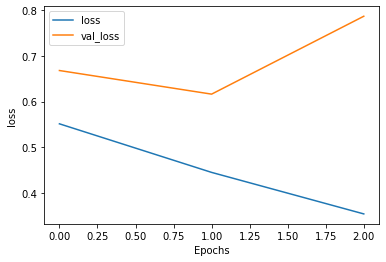

In [47]:
import matplotlib.pyplot as plt

# Plot Utility
def plot_graphs(history, string):
    plt.plot(history.history[string])
    plt.plot(history.history['val_'+string])
    plt.xlabel("Epochs")
    plt.ylabel(string)
    plt.legend([string, 'val_'+string])
    plt.show()

plot_graphs(history, "loss")

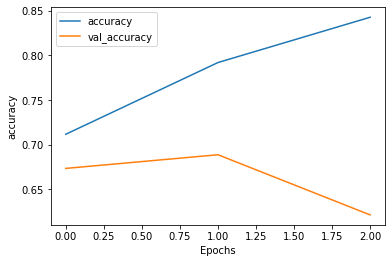

In [48]:
plot_graphs(history, "accuracy")

데이터 제출하기

In [ ]:
TEST_Q1_DATA_FILE = "test_q1.npy"
TEST_Q2_DATA_FILE = "test_q2.npy"
TEST_ID_DATA_FILE = "test_id.npy"

test_q1_data = np.load(open(DATA_IN_PATH + TEST_Q1_DATA_FILE, "rb"))
test_q2_data = np.load(open(DATA_IN_PATH + TEST_Q2_DATA_FILE, "rb"))
test_id_data = np.load(open(DATA_IN_PATH + TEST_ID_DATA_FILE, "rb"), allow_pickle=True)

SAVE_FILE_NM = "weights.h5"
Model.load_weights(os.path.join(DATA_OUT_PATH, model_name, SAVE_FILE_NM))

predictions = Model.predict((test_q1_data, test_q2_data), batch_size=BATCH_SIZE)
predictions = predictions.squeeze(-1)

output = pd.DataFrame(data = {"test_id" : test_id_data,
                            "is_duplicate" : list(predictions)})
output.to_csv("./data_out/cnn_predict.csv", index = False, quoting=3)

MaLSTM 텍스트 유사도 분석 모델

모델 소개
- 맨하튼 거리 + LSTM
- 코사인 유사도 대신 맨하튼 거리를 사용하는 모델

In [1]:
import tensorflow as tf
from tensorflow.python.keras.preprocessing.sequence import pad_sequences
from tensorflow.python.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.python.keras import layers
import numpy as np
import json

In [4]:
DATA_IN_PATH = './data_in/'
DATA_OUT_PATH = './data_out/'

TRAIN_Q1_DATA_FILE = 'train_q1.npy'
TRAIN_Q2_DATA_FILE = 'train_q2.npy'
TRAIN_LABEL_DATA_FILE = 'train_label.npy'
DATA_CONFIGS = 'data_configs.json'

q1_data = np.load(open(DATA_IN_PATH + TRAIN_Q1_DATA_FILE, 'rb'))
q2_data = np.load(open(DATA_IN_PATH + TRAIN_Q2_DATA_FILE, 'rb'))
labels = np.load(open(DATA_IN_PATH + TRAIN_LABEL_DATA_FILE, 'rb'))
prepro_configs = json.load(open(DATA_IN_PATH + DATA_CONFIGS, "r"))  # 사전 정보. 워드 임베딩에 사용

In [2]:
class Model(tf.keras.Model):
    def __init__(self, **kargs):
        super(Model, self).__init__(name = model_name)
        
        # 임베딩 층
        self.embedding = layers.Embedding(input_dim = kargs["vocab_size"],
                                        output_dim = kargs["embedding_dimention"])
        
        # LSTM 층
        self.lstm = layers.LSTM(units = kargs["lstm_dimention"])
    
    # 입력값에 대해 연산 진행
    def call(self, x):
        x1, x2 = x
        x1 = self.embedding(x1)
        x2 = self.embedding(x2)
        
        x1 = self.lstm(x1)
        x2 = self.lstm(x2)
        
        # 맨하튼 거리 계산
        x = tf.exp(-tf.reduce_sum(tf.abs(x1 - x2), axis = 1))
        
        return x

In [6]:
# 하이퍼파라미터 정의
model_name = "malstm_similarity"
BATCH_SIZE = 128
NUM_EPOCHS = 5
VALID_SPLIT = 0.1

kargs = {
    "vocab_size" : prepro_configs["vocab_size"],
    "embedding_dimention" : 100,
    "lstm_dimention" : 150
}

model = Model(**kargs)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
            loss=tf.keras.losses.BinaryCrossentropy(),
            metrics=tf.keras.metrics.BinaryAccuracy(name="accuracy"))

In [9]:
# 오버피팅을 막기 위한 earlystop 추가
import os

earlystop_callboack = EarlyStopping(
    monitor = "val_accuracy", min_delta = 0.0001, patience = 1
)

checkpoint_path = DATA_OUT_PATH + model_name + "/weights.h5"
checkpoint_dir = os.path.dirname(checkpoint_path)

if os.path.exists(checkpoint_dir):
    print("{} -- Folder already exists \n".format(checkpoint_dir))
else:
    os.makedirs(checkpoint_dir, exist_ok=True)
    print("{} -- Folder create complete \n".format(checkpoint_dir))

cp_callback = ModelCheckpoint(
    checkpoint_path, monitor = "val_accuracy", verbose = 1, save_best_only = True,
    save_weights_only = True
)

history = model.fit((q1_data, q2_data), labels, batch_size=BATCH_SIZE, epochs=NUM_EPOCHS,
                    validation_split=VALID_SPLIT, callbacks = [earlystop_callboack, cp_callback])

./data_out/malstm_similarity -- Folder create complete 

Epoch 1/5
2100/2100 [==============================] - ETA: 0s - loss: 0.5240 - accuracy: 0.7462
Epoch 00001: val_accuracy improved from -inf to 0.68540, saving model to ./data_out/malstm_similarity/weights.h5
2100/2100 [==============================] - 437s 208ms/step - loss: 0.5240 - accuracy: 0.7462 - val_loss: 0.5776 - val_accuracy: 0.6854
Epoch 2/5
2100/2100 [==============================] - ETA: 0s - loss: 0.4040 - accuracy: 0.8232
Epoch 00002: val_accuracy improved from 0.68540 to 0.78328, saving model to ./data_out/malstm_similarity/weights.h5
2100/2100 [==============================] - 426s 203ms/step - loss: 0.4040 - accuracy: 0.8232 - val_loss: 0.4390 - val_accuracy: 0.7833
Epoch 3/5
2100/2100 [==============================] - ETA: 0s - loss: 0.3551 - accuracy: 0.8511
Epoch 00003: val_accuracy improved from 0.78328 to 0.82280, saving model to ./data_out/malstm_similarity/weights.h5
2100/2100 [======================

데이터 제출하기

In [12]:
import pandas as pd

TEST_Q1_DATA_FILE = "test_q1.npy"
TEST_Q2_DATA_FILE = "test_q2.npy"
TEST_ID_DATA_FILE = "test_id.npy"

test_q1_data = np.load(open(DATA_IN_PATH + TEST_Q1_DATA_FILE, "rb"))
test_q2_data = np.load(open(DATA_IN_PATH + TEST_Q2_DATA_FILE, "rb"))
test_id_data = np.load(open(DATA_IN_PATH + TEST_ID_DATA_FILE, "rb"), allow_pickle=True)

SAVE_FILE_NM = "weights.h5"
model.load_weights(os.path.join(DATA_OUT_PATH, model_name, SAVE_FILE_NM))

predictions = model.predict((test_q1_data, test_q2_data), batch_size=BATCH_SIZE)
predictions = predictions.squeeze()

output = pd.DataFrame(data = {"test_id" : test_id_data,
                            "is_duplicate" : list(predictions)})
output.to_csv("./data_out/malstm_predict.csv", index = False, quoting=3)